In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
from notebooks.ablations_baselines import *
from notebooks.figures import FONTSIZE

In [3]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("xpmir/cross-encoder-bert-base-infoNCE")

NUM_HEADS = config.num_attention_heads
NUM_LAYERS = config.num_hidden_layers
HIDDEN_DIM = config.intermediate_size

print(f"NUM_HEADS: {NUM_HEADS}, NUM_LAYERS: {NUM_LAYERS}, HIDDEN_DIM: {HIDDEN_DIM}")

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


NUM_HEADS: 12, NUM_LAYERS: 12, HIDDEN_DIM: 3072


In [4]:
# monobert_base percentage degradations

monobert_base_degradation = {
    'trec_dl19': (monobert_base_trec_dl19 - trec_dl19) / monobert_base_trec_dl19,
    'trec_dl20': (monobert_base_trec_dl20 - trec_dl20) / monobert_base_trec_dl20,
    'trec_dl21': (monobert_base_trec_dl21 - trec_dl21) / monobert_base_trec_dl21,
    'trec_dl22': (monobert_base_trec_dl22 - trec_dl22) / monobert_base_trec_dl22,
    'nfcorpus': (monobert_base_nfcorpus - nfcorpus) / monobert_base_nfcorpus,
    'fiqa': (monobert_base_fiqa - fiqa) / monobert_base_fiqa,
    'trec_covid': (monobert_base_trec_covid - trec_covid) / monobert_base_trec_covid,
    'robust_04': (monobert_base_robust_04 - robust_04) / monobert_base_robust_04,
    'nq': (monobert_base_nq - nq) / monobert_base_nq,
    'bioasq': (monobert_base_bioasq - bioasq) / monobert_base_bioasq,
}

monobert_base_msmarcos_degradation = {
    'trec_dl19': (monobert_base_trec_dl19 - trec_dl19) / monobert_base_trec_dl19,
    'trec_dl20': (monobert_base_trec_dl20 - trec_dl20) / monobert_base_trec_dl20,
    'trec_dl21': (monobert_base_trec_dl21 - trec_dl21) / monobert_base_trec_dl21,
    'trec_dl22': (monobert_base_trec_dl22 - trec_dl22) / monobert_base_trec_dl22,
}

monobert_base_ood_degradation = {
    'nfcorpus': (monobert_base_nfcorpus - nfcorpus) / monobert_base_nfcorpus,
    'fiqa': (monobert_base_fiqa - fiqa) / monobert_base_fiqa,
    'trec_covid': (monobert_base_trec_covid - trec_covid) / monobert_base_trec_covid,
    'robust_04': (monobert_base_robust_04 - robust_04) / monobert_base_robust_04,
    'nq': (monobert_base_nq - nq) / monobert_base_nq,
    'bioasq': (monobert_base_bioasq - bioasq) / monobert_base_bioasq,
}

print("monobert_base degradation (%):", monobert_base_degradation)

# Prepare a summary DataFrame for mean and variance of each degradation dictionary
degradation_dicts = {
    'monobert_base_degradation': monobert_base_degradation,
    'monobert_base_msmarcos_degradation': monobert_base_msmarcos_degradation,
    'monobert_base_ood_degradation': monobert_base_ood_degradation,
}

summary = []
for name, d in degradation_dicts.items():
    values = list(d.values())
    summary.append({
        'name': name,
        'mean': 1 - np.mean(values),
        'std': np.std(values)
    })

degradation_stats_df = pd.DataFrame(summary)
print(degradation_stats_df)

monobert_base degradation (%): {'trec_dl19': 0.7037037037037037, 'trec_dl20': 0.782051282051282, 'trec_dl21': 0.6883116883116883, 'trec_dl22': 0.7428571428571429, 'nfcorpus': 0.5306122448979592, 'fiqa': 0.8947368421052632, 'trec_covid': 0.4666666666666666, 'robust_04': 0.62, 'nq': 0.8333333333333333, 'bioasq': 0.888888888888889}
                                 name      mean       std
0           monobert_base_degradation  0.284884  0.136876
1  monobert_base_msmarcos_degradation  0.270769  0.036406
2       monobert_base_ood_degradation  0.294294  0.173551


# MSM

In [5]:
# Doc-->Doc ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/e86a4d280015fe32419dd9992e2932da3cdba0f898a399c90b6304e9c77024cd/storage/summary_results.csv'
doc_to_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_to_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_to_doc_csv = doc_to_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_to_doc_csv['Layer'] = range(len(doc_to_doc_csv))
# Display the first few rows of the DataFrame
doc_to_doc_csv['mean'] = 1 - doc_to_doc_csv['mean']
print(doc_to_doc_csv.head())

   Layer      mean       std
0      0  0.998700  0.005013
1      1  0.987690  0.004069
2      2  0.959214  0.010489
3      3  0.898629  0.030498
4      4  0.858209  0.044990


In [6]:
# All-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/07e07f6683d4992df25f95bba73944b48cc1562e70c0641bb85f20e5937db1d0/storage/summary_results.csv'
all_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
all_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
all_to_cls_csv = all_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
all_to_cls_csv['Layer'] = range(len(all_to_cls_csv))
all_to_cls_csv['mean'] = 1 - all_to_cls_csv['mean']

# Display the first few rows of the DataFrame
print(all_to_cls_csv.head())

   Layer      mean       std
0      0  1.001873  0.002106
1      1  1.001964  0.003598
2      2  1.000995  0.005335
3      3  1.001737  0.003952
4      4  0.999730  0.002436


In [7]:
# Query + Doc --> CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/28f154444babcfaf0ce8ad3dfd245528a9008394dce9c3d223a0911ebcc928d1/storage/summary_results.csv'
query_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_doc_to_cls_csv = query_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_doc_to_cls_csv['Layer'] = range(len(query_doc_to_cls_csv))
query_doc_to_cls_csv['mean'] = 1 - query_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_doc_to_cls_csv.head())

   Layer      mean       std
0      0  1.001249  0.001004
1      1  1.002308  0.002646
2      2  1.001318  0.004156
3      3  1.001269  0.003934
4      4  0.991817  0.003753


In [8]:
# Doc + Query --> Doc + Query ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/5e761ea59353232602f8b50751e845ca9bbb0c6007e8c0103ed7c44e52fcdcde/storage/summary_results.csv'
doc_query_to_doc_query_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_query_to_doc_query_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_query_to_doc_query_csv = doc_query_to_doc_query_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_query_to_doc_query_csv['Layer'] = range(len(doc_query_to_doc_query_csv))
doc_query_to_doc_query_csv['mean'] = 1 - doc_query_to_doc_query_csv['mean']
# Display the first few rows of the DataFrame
print(doc_query_to_doc_query_csv.head())

   Layer      mean       std
0      0  0.995162  0.006661
1      1  0.980752  0.005499
2      2  0.939229  0.012553
3      3  0.843393  0.037049
4      4  0.688328  0.051046


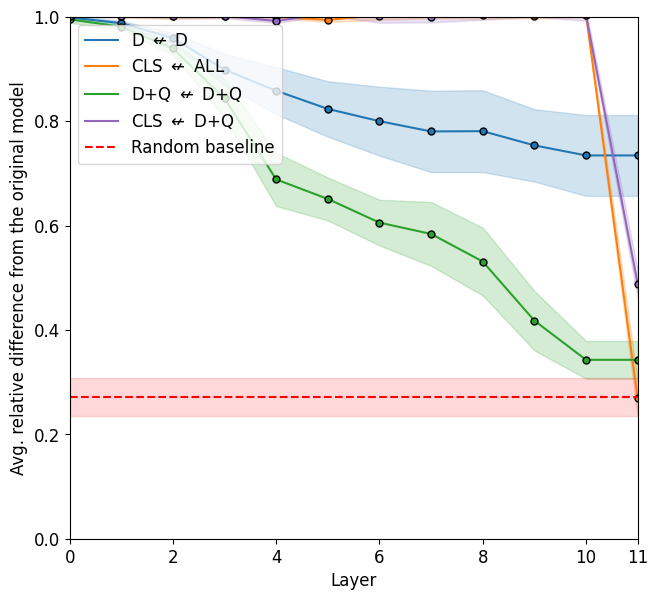

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': FONTSIZE})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'D $\nleftarrow$ D',
        'df': doc_to_doc_csv,
        'highlight': doc_to_doc_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ ALL',
        'df': all_to_cls_csv,
        'highlight': all_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'D+Q $\nleftarrow$ D+Q',
        'df': doc_query_to_doc_query_csv,
        'highlight': doc_query_to_doc_query_csv['Layer'].tolist(),
        'color': palette[2]
    },
    {
        'label': r'CLS $\nleftarrow$ D+Q',
        'df': query_doc_to_cls_csv,
        'highlight': query_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[4]
    }
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=NUM_LAYERS - 1)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, NUM_LAYERS, 2), [NUM_LAYERS - 1]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')

# Add horizontal red bar for monobert_base MSMARCOs average and variance
mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_base_msmarcos_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_base_msmarcos_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

# Save and show
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
plt.savefig("./images/monobert_base_msmarco_ablations.pdf", format="pdf")
plt.show()


# OOD

In [10]:
# Doc-->Doc ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/3421e420ab6991a9e255878293fe4a87eb1fb66c2897fb36e3882eaa2a701539/storage/summary_results.csv'
doc_to_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_to_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_to_doc_csv = doc_to_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_to_doc_csv['Layer'] = range(len(doc_to_doc_csv))
doc_to_doc_csv['mean'] = 1 - doc_to_doc_csv['mean']
# Display the first few rows of the DataFrame
print(doc_to_doc_csv.head())

   Layer      mean       std
0      0  0.995714  0.005421
1      1  0.980478  0.006583
2      2  0.954254  0.017983
3      3  0.878665  0.042475
4      4  0.837770  0.058160


In [11]:
# All-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/ba71edea99180fad3f1fccdd7b237953d06bda66fe50498fb42a5784945ae415/storage/summary_results.csv'
all_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
all_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
all_to_cls_csv = all_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
all_to_cls_csv['Layer'] = range(len(all_to_cls_csv))
all_to_cls_csv['mean'] = 1 - all_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(all_to_cls_csv.head())

   Layer      mean       std
0      0  0.998368  0.005017
1      1  0.999969  0.005395
2      2  0.999045  0.005452
3      3  0.997526  0.006981
4      4  0.995328  0.011016


In [12]:
# Query + Doc --> CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/66e72768ef9ead43311fa31656b8a19ed0a4ff80166b1de82c7cb6b585a19579/storage/summary_results.csv'
query_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_doc_to_cls_csv = query_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_doc_to_cls_csv['Layer'] = range(len(query_doc_to_cls_csv))
query_doc_to_cls_csv['mean'] = 1 - query_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_doc_to_cls_csv.head())

   Layer      mean       std
0      0  0.998564  0.005687
1      1  0.999389  0.005463
2      2  1.000009  0.005570
3      3  0.998259  0.005752
4      4  0.969990  0.018658


In [13]:
# Doc + Query --> Doc + Query ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/c8284ed3e7d7b43baf3177e515c4bf02e6b39159fa31fee102d3626fd64d9a07/storage/summary_results.csv'
doc_query_to_doc_query_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_query_to_doc_query_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_query_to_doc_query_csv = doc_query_to_doc_query_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_query_to_doc_query_csv['Layer'] = range(len(doc_query_to_doc_query_csv))
doc_query_to_doc_query_csv['mean'] = 1 - doc_query_to_doc_query_csv['mean']
# Display the first few rows of the DataFrame
print(doc_query_to_doc_query_csv)

    Layer      mean       std
0       0  0.990323  0.006941
1       1  0.970621  0.007494
2       2  0.928938  0.023645
3       3  0.801815  0.063815
4       4  0.683913  0.091331
5       5  0.648543  0.109722
6       6  0.644354  0.122371
7       7  0.671548  0.120529
8       8  0.648711  0.121004
9       9  0.562408  0.133327
10     10  0.499232  0.166232
11     11  0.499232  0.166232


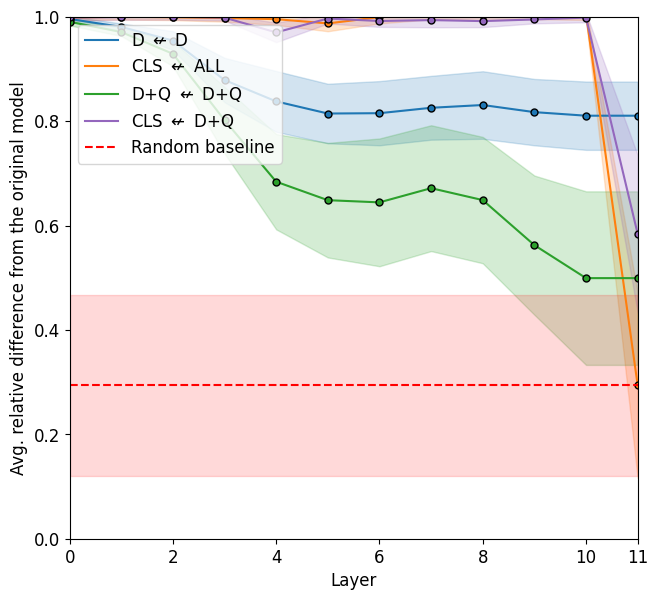

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': FONTSIZE})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'D $\nleftarrow$ D',
        'df': doc_to_doc_csv,
        'highlight': doc_to_doc_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ ALL',
        'df': all_to_cls_csv,
        'highlight': all_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'D+Q $\nleftarrow$ D+Q',
        'df': doc_query_to_doc_query_csv,
        'highlight': doc_query_to_doc_query_csv['Layer'].tolist(),
        'color': palette[2]
    },
    {
        'label': r'CLS $\nleftarrow$ D+Q',
        'df': query_doc_to_cls_csv,
        'highlight': query_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[4]
    }
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=NUM_LAYERS - 1)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, NUM_LAYERS, 2), [NUM_LAYERS - 1]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')

mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_base_ood_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_base_ood_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

# Save and show
plt.legend(loc='upper left')
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
plt.savefig("./images/monobert_base_ood_ablations.pdf", format="pdf")
plt.show()


# ALL

In [15]:
# Doc-->Doc ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/1c527b56a973887c670bb58e337ae1107f1d7ab79870ef86f2e01406070951a1/storage/summary_results.csv'
doc_to_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_to_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_to_doc_csv = doc_to_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_to_doc_csv['Layer'] = range(len(doc_to_doc_csv))
doc_to_doc_csv['mean'] = 1 - doc_to_doc_csv['mean']
# Display the first few rows of the DataFrame
print(doc_to_doc_csv.head())

   Layer      mean       std
0      0  0.996908  0.005461
1      1  0.983363  0.006716
2      2  0.956238  0.015619
3      3  0.886651  0.039372
4      4  0.845946  0.054217


In [16]:
# All-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/03510a0450541edaa99e6b91614cd057b10be2e8306bd10c2c2f6156c873e7d6/storage/summary_results.csv'
all_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
all_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
all_to_cls_csv = all_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
all_to_cls_csv['Layer'] = range(len(all_to_cls_csv))
all_to_cls_csv['mean'] = 1 - all_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(all_to_cls_csv.head())

   Layer      mean       std
0      0  0.999770  0.004453
1      1  1.000767  0.004857
2      2  0.999825  0.005489
3      3  0.999211  0.006304
4      4  0.997089  0.008935


In [17]:
# Query + Doc --> CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/e6adb8476dc44870d616b6663b387650d73fc2d9490f1465b9a6901fe202565d/storage/summary_results.csv'
query_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_doc_to_cls_csv = query_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_doc_to_cls_csv['Layer'] = range(len(query_doc_to_cls_csv))
query_doc_to_cls_csv['mean'] = 1 - query_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_doc_to_cls_csv.head())

   Layer      mean       std
0      0  0.999638  0.004641
1      1  1.000557  0.004770
2      2  1.000533  0.005093
3      3  0.999463  0.005312
4      4  0.978720  0.018134


In [18]:
# Doc + Query --> Doc + Query ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/f15db864a5b44550b135d31da8df51fd2c66529ac8c914d867f0aedb494a1534/storage/summary_results.csv'
doc_query_to_doc_query_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_query_to_doc_query_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_query_to_doc_query_csv = doc_query_to_doc_query_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_query_to_doc_query_csv['Layer'] = range(len(doc_query_to_doc_query_csv))
doc_query_to_doc_query_csv['mean'] = 1 - doc_query_to_doc_query_csv['mean']
# Display the first few rows of the DataFrame
print(doc_query_to_doc_query_csv.head())

   Layer      mean       std
0      0  0.992259  0.007230
1      1  0.974673  0.008392
2      2  0.933054  0.020589
3      3  0.818446  0.058372
4      4  0.685679  0.077793


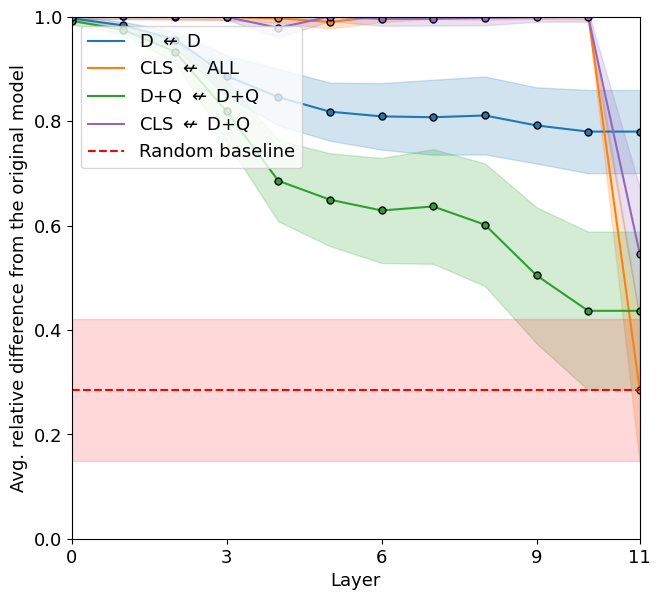

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 13})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'D $\nleftarrow$ D',
        'df': doc_to_doc_csv,
        'highlight': doc_to_doc_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ ALL',
        'df': all_to_cls_csv,
        'highlight': all_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'D+Q $\nleftarrow$ D+Q',
        'df': doc_query_to_doc_query_csv,
        'highlight': doc_query_to_doc_query_csv['Layer'].tolist(),
        'color': palette[2]
    },
    {
        'label': r'CLS $\nleftarrow$ D+Q',
        'df': query_doc_to_cls_csv,
        'highlight': query_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[4]
    }
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=NUM_LAYERS - 1)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, NUM_LAYERS, 3), [NUM_LAYERS - 1]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')

mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_base_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_base_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

plt.legend(loc='upper left')
# Save and show
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
plt.savefig("./images/monobert_base_all_ablations.pdf", format="pdf")
plt.show()
